# OASIS pilot → SpatialData

`cpio.read_plate` reads one plate of a Cell Painting Gallery source into a [SpatialData](https://spatialdata.scverse.org) object.
Fields of view become Images, the CellProfiler Nuclei, Cells and Cytoplasm segmentations become Labels, the wells become Shapes where the source recorded stage coordinates, and the well- and cell-level measurements become the `wells` and `cells` Tables.

One well of `cpg0033-oasis-pilot`, fetched with the script beside this notebook:

```bash
python fetch.py cpg0033-oasis-pilot/broad 2024_03_29_OASIS_U2OS_AssayDev BR00142737 A01
```

In [1]:
from __future__ import annotations

import logging
import warnings
from pathlib import Path

import numpy as np
import spatialdata as sd
import spatialdata_plot  # noqa: F401
from matplotlib.colors import Normalize

import cell_painting_io as cpio

# ome-zarr logs a line per label element on read, and spatialdata-plot warns once per element it subsets out
logging.getLogger("ome_zarr").setLevel(logging.ERROR)
warnings.filterwarnings("ignore", message="The table is annotating .*, which is not present")

DATA_ROOT = Path("~/data/cpg0033-oasis-pilot/broad").expanduser()
BATCH = "2024_03_29_OASIS_U2OS_AssayDev"
PLATE = "BR00142737"
CHANNEL = "DNA"

/home/lheumos/miniforge3/envs/cell-painting-io/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
sdata = cpio.read_plate(DATA_ROOT, BATCH, PLATE, profile="normalized_feature_select_batch")
sdata

/home/lheumos/miniforge3/envs/cell-painting-io/lib/python3.14/functools.py:982: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


SpatialData object
├── Images
│     ├── 'BR00142737_A01_s1_image': DataTree[cyx] (6, 1080, 1080), (6, 540, 540), (6, 270, 270)
│     ├── 'BR00142737_A01_s2_image': DataTree[cyx] (6, 1080, 1080), (6, 540, 540), (6, 270, 270)
│     ├── 'BR00142737_A01_s3_image': DataTree[cyx] (6, 1080, 1080), (6, 540, 540), (6, 270, 270)
│     ├── 'BR00142737_A01_s4_image': DataTree[cyx] (6, 1080, 1080), (6, 540, 540), (6, 270, 270)
│     ├── 'BR00142737_A01_s5_image': DataTree[cyx] (6, 1080, 1080), (6, 540, 540), (6, 270, 270)
│     ├── 'BR00142737_A01_s6_image': DataTree[cyx] (6, 1080, 1080), (6, 540, 540), (6, 270, 270)
│     ├── 'BR00142737_A01_s7_image': DataTree[cyx] (6, 1080, 1080), (6, 540, 540), (6, 270, 270)
│     ├── 'BR00142737_A01_s8_image': DataTree[cyx] (6, 1080, 1080), (6, 540, 540), (6, 270, 270)
│     └── 'BR00142737_A01_s9_image': DataTree[cyx] (6, 1080, 1080), (6, 540, 540), (6, 270, 270)
├── Labels
│     ├── 'BR00142737_A01_s1_cells': DataArray[yx] (1080, 1080)
│     ├── 'BR00142737_

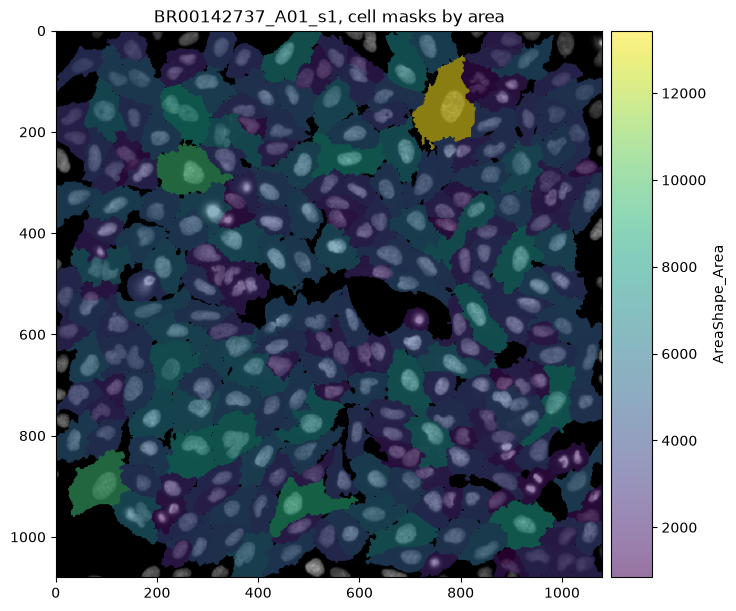

In [3]:
fov = next(name.removesuffix("_cells") for name in sdata.labels if name.endswith("_cells"))
values = sd.get_pyramid_levels(sdata[f"{fov}_image"], n=0).sel(c=CHANNEL).to_numpy()
(
    sdata.pl.render_images(
        f"{fov}_image", channel=CHANNEL, cmap="gray", norm=Normalize(*np.percentile(values, [50, 99.9])), colorbar=False
    )
    .pl.render_labels(f"{fov}_cells", color="AreaShape_Area", table_name="cells", fill_alpha=0.55)
    .pl.show(coordinate_systems=fov, figsize=(6.5, 6), title=f"{fov}, cell masks by area")
)